# IT25101908 — Missing Value Handling
Technique: Median Imputation for age

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load raw dataset
df = pd.read_csv("../data/raw/HAM10000_metadata.csv")

print(df.shape)
df.info()
df.head()

(10015, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [2]:
df.isnull().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

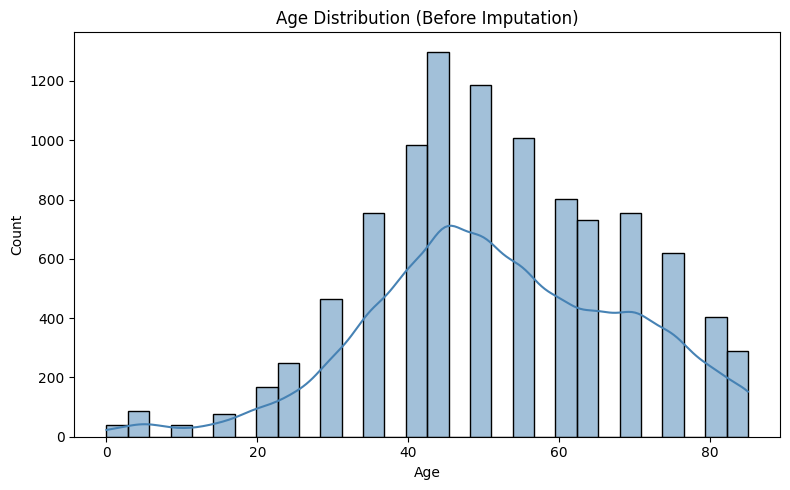

In [3]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'].dropna(), bins=30, kde=True, color='steelblue')
plt.title('Age Distribution (Before Imputation)')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/age_distribution_before.png', dpi=150)
plt.show()

In [4]:
median_age = df['age'].median()
print("Median age:", median_age)

df['age'] = df['age'].fillna(median_age)

# Confirm no missing values remain
print(df['age'].isnull().sum())

Median age: 50.0
0


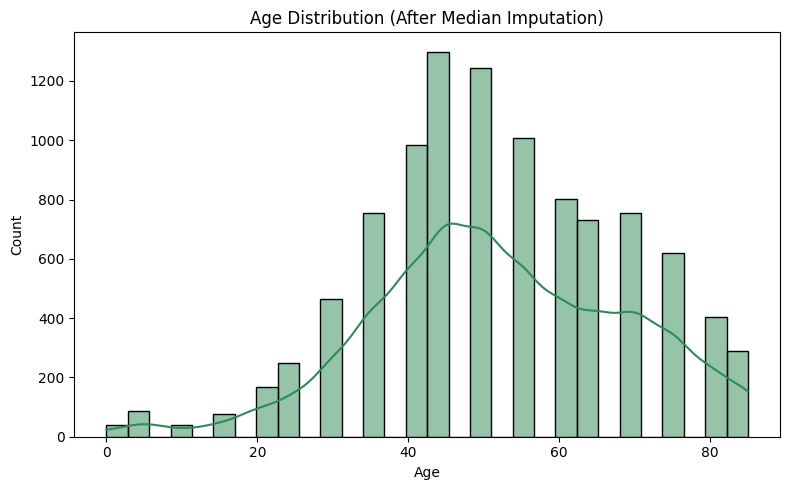

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True, color='seagreen')
plt.title('Age Distribution (After Median Imputation)')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/age_distribution_after.png', dpi=150)
plt.show()

## Interpretation

The age distribution is roughly centered between 40-60 years, with a slight right skew. After median imputation, the overall shape of the distribution is preserved — the imputed values sit at the median rather than distorting the tails, confirming median imputation did not introduce bias into the age feature.

In [6]:
df.to_csv("../results/outputs/missingvalues_step_output.csv", index=False)